In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score,f1_score
import joblib

In [127]:
#EDA
col_names=['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']
data = pd.read_csv("IRIS (4).csv")
data.columns = col_names
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Species        0
dtype: int64

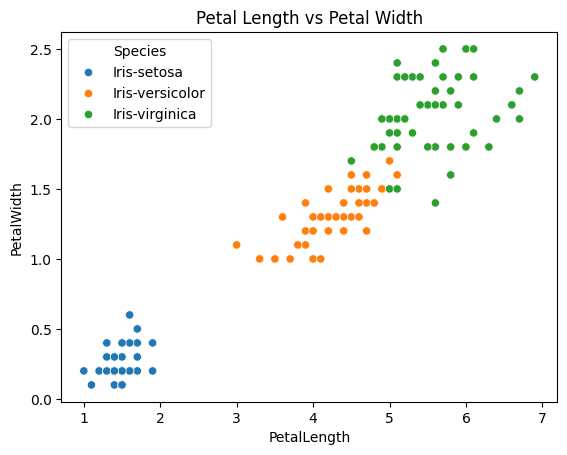

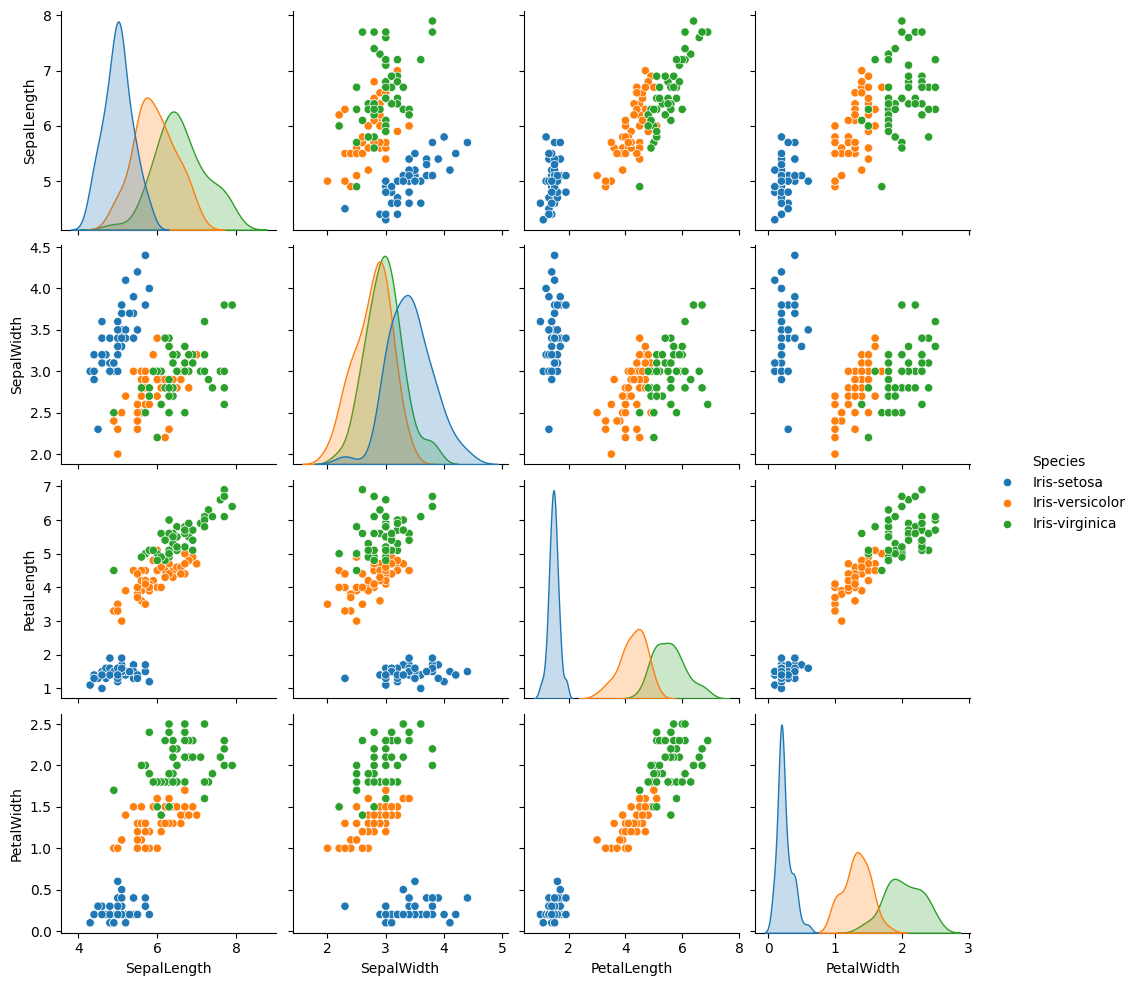

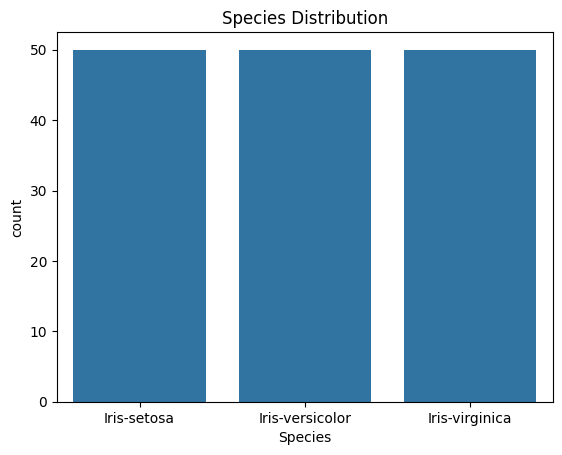

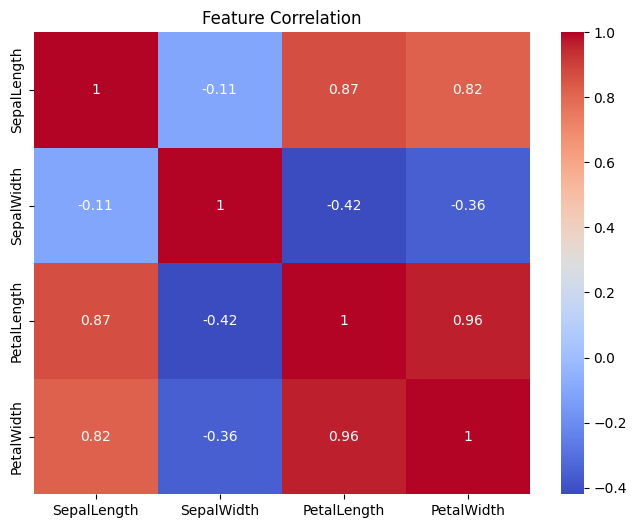

In [128]:
#Class Separability Visualization
#1. Scatter Plot
sns.scatterplot(
    data=data,
    x='PetalLength',
    y='PetalWidth',
    hue='Species'
)
plt.title("Petal Length vs Petal Width")
plt.show()

#2. Pair Plot
sns.pairplot(data, hue='Species')
plt.show()

#3. Count Plot
sns.countplot(x='Species', data=data)
plt.title("Species Distribution")
plt.show()

#4. HeatMap of Correlation
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [129]:
#Training
x=data.iloc[:,:-1]
y=data['Species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#1. KNN
knn=KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn.fit(x_train_scaled,y_train)
knn_pred=knn.predict(x_test_scaled)

#2. Logistic Regression
lr=LogisticRegression(max_iter=200,random_state=42)
lr.fit(x_train_scaled,y_train)
lr_pred=lr.predict(x_test_scaled)

#3. Decision Tree
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled,y_train)
dt_pred=dt.predict(x_test_scaled)

----
k-NN
----
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


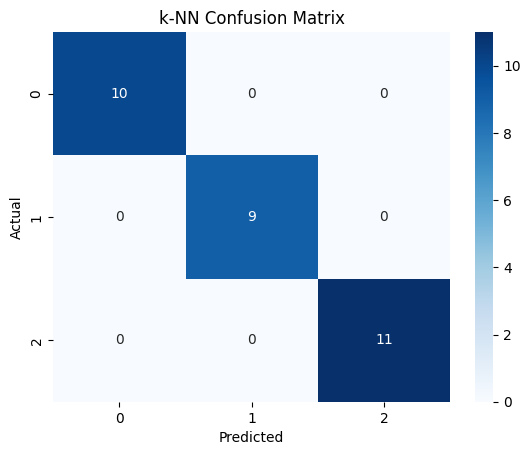

-------------------
Logistic Regression
-------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


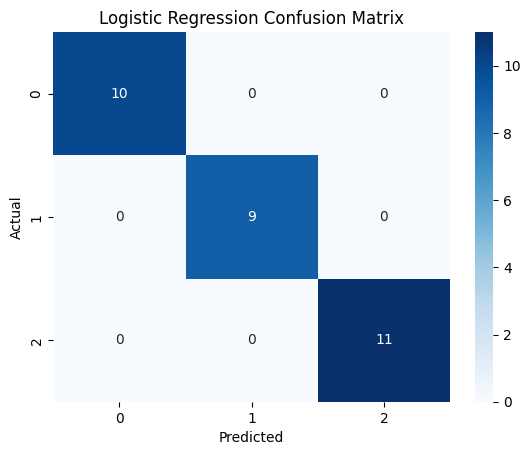

-------------
Decision Tree
-------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


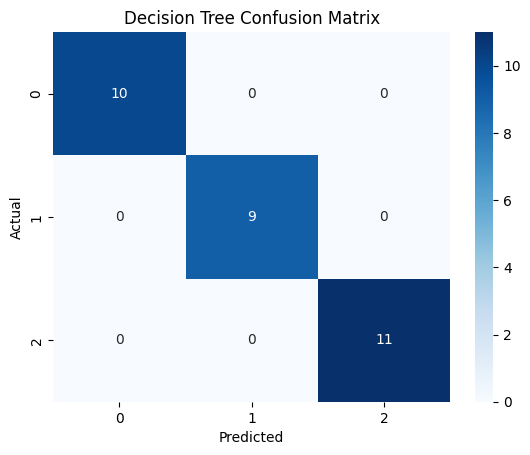

In [130]:
#Model metrics and evaluation
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average='macro'
    )
    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )
    f1score = f1_score(
        y_test,
        y_pred,
        average='macro'
    )
    conf_matrix = confusion_matrix(
        y_test,
        y_pred
    )

    print("-"*len(name)+f"\n{name}"+"\n"+"-"*len(name))
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1score)
    print("Confusion Matrix:\n", conf_matrix)

    

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    return accuracy

knn_acc = evaluate_model(
    "k-NN",
    y_test,
    knn_pred
)

lr_acc = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

dt_acc = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

In [131]:
#Best Model Selection
accuracies = {
    "KNN": knn_acc,
    "Logistic Regression": lr_acc,
    "Decision Tree": dt_acc
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

print("Best Model:", best_model_name)
print("Model's Accuracy Score:", accuracies[best_model_name])

models = {
    "KNN": knn,
    "Logistic Regression": lr,
    "Decision Tree": dt
}
best_model = models[best_model_name]
joblib.dump(
    best_model,
    "best_iris_model.pkl"
)
print("Model Saved")

Best Model: KNN
Model's Accuracy Score: 1.0
Model Saved


In [132]:
#Example Inference Code
model = joblib.load(
    "best_iris_model.pkl"
)
print("Model Loaded")
sl=float(input("Enter Sepal Length: "))
sw=float(input("Enter Sepal Width: "))
pl=float(input("Enter Petal Length: "))
pw=float(input("Enter Petal Width: "))
sample = pd.DataFrame(
    [[sl, sw, pl, pw]],
    columns=[
        'SepalLength',
        'SepalWidth',
        'PetalLength',
        'PetalWidth'
    ]
)
scaled_sample = scaler.transform(sample)
prediction = model.predict(scaled_sample)

print(
    "Predicted Species:",
    prediction[0]
)

Model Loaded


Predicted Species: Iris-versicolor
